<a href="https://colab.research.google.com/github/reshmajayaghosh/Bank-Loan-Report/blob/main/greeshma_exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Task 1: Dataset Exploration and Preparation:**

In [ ]:
#Load Dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [ ]:
import os
os.listdir('/kaggle/input/intel-image-classification')

['seg_train', 'seg_pred', 'seg_test']

In [ ]:
#Split the dataset into training, validation, and test sets.

train_path = "/kaggle/input/intel-image-classification/seg_train/seg_train"
test_path = "/kaggle/input/intel-image-classification/seg_test/seg_test"
validation_path = "/kaggle/input/intel-image-classification/seg_val/seg_val"

In [ ]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [ ]:
#Inspect Image classes
classes = os.listdir(train_path)

for cls in classes:
    folder = os.path.join(train_path, cls)
    count = len(os.listdir(folder))
    print(f"{cls}: {count}")

mountain: 2512
street: 2382
buildings: 2191
sea: 2274
forest: 2271
glacier: 2404


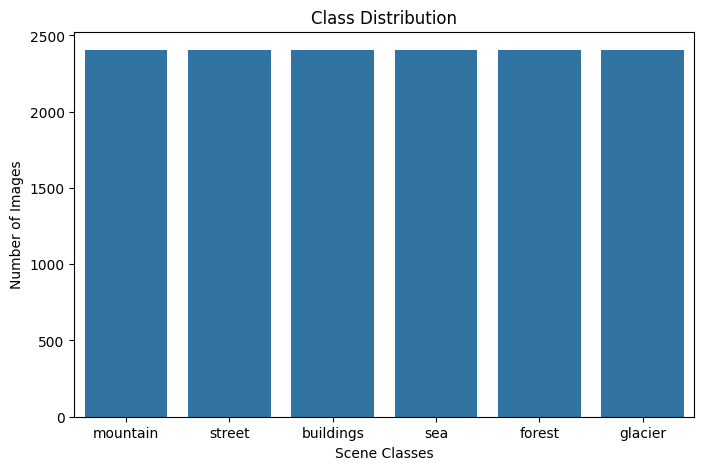

In [ ]:
#Inspect Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns

counts = []
for cls in classes:
    counts.append(len(os.listdir(folder)))

plt.figure(figsize=(8,5))
sns.barplot(x=classes,y=counts)
plt.title("Class Distribution")
plt.xlabel("Scene Classes")
plt.ylabel("Number of Images")
plt.show()

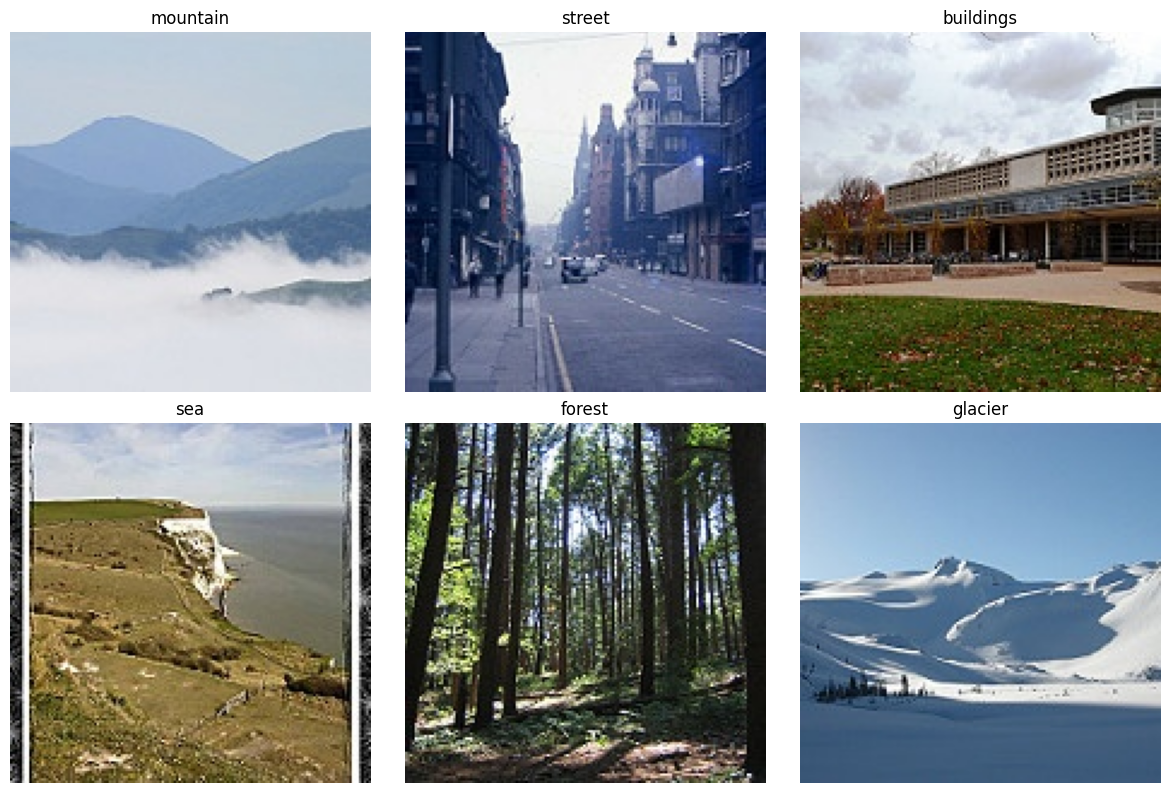

In [ ]:
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    image_name = os.listdir(os.path.join(train_path, cls))[0]
    image_path = os.path.join(train_path,cls,image_name)
    img = load_img(image_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Resize images to a uniform input size

IMG_SIZE = (150,150)
BATCH_SIZE = 32
print("All images will be resized to:", IMG_SIZE)

All images will be resized to: (150, 150)


**Analytical Question 1 :
What challenges do variations in lighting, viewpoint, and class imbalance introduce in satellite scene
classification?**


* Variations in lighting can change the appearance of objects and surfaces, making classification difficult.
* Different viewpoints may show the same scene from different angles, affecting feature extraction.
* Class imbalance can cause the model to focus more on classes with larger numbers of samples, reducing performance on less represented classes.

#**Task 2: Data Preprocessing and Augmentation**

In [ ]:
#Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#Training Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 11230 images belonging to 6 classes.


In [ ]:
#Validation Generator
val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2804 images belonging to 6 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
sample_batch, sample_labels = next(train_generator)

print(sample_batch.shape)

Found 3000 images belonging to 6 classes.
(32, 150, 150, 3)


**Analytical Question 2 (Markdown):
How does data augmentation help reduce overfitting in image-based deep learning models?**

* Data augmentation helps reduce overfitting by creating modified versions of existing training images.
* Techniques such as rotation, zooming, shifting, and flipping introduce variations in the dataset without collecting new images. As a result, the model learns more general features instead of memorizing specific training samples.
* This improves the model's ability to perform well on unseen images and enhances overall generalization.

#**Task 3: Model Design and Training**

Design and train a convolutional neural network (CNN) for multi-class classification.

In [ ]:
#Build CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolution Block
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Comiple Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 144s 392ms/step - accuracy: 0.5226 - loss: 1.1999 - val_accuracy: 0.6673 - val_loss: 0.8653
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 233ms/step - accuracy: 0.6182 - loss: 1.0057 - val_accuracy: 0.6180 - val_loss: 1.0037
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 242ms/step - accuracy: 0.6675 - loss: 0.8909 - val_accuracy: 0.6833 - val_loss: 0.8077
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 245ms/step - accuracy: 0.6959 - loss: 0.8248 - val_accuracy: 0.7953 - val_loss: 0.6033
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 239ms/step - accuracy: 0.7320 - loss: 0.7482 - val_accuracy: 0.8003 - val_loss: 0.5742
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 232ms/step - accuracy: 0.7344 - loss: 0.7298 - val_accuracy: 0.7693 - val_loss: 0.6135
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 238ms/step - accuracy: 0.7630 - loss: 0.6746 - val_accuracy: 0.8106 - val_loss: 0.5347
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 227ms/step - accuracy: 0.7683 - loss: 

**INSIGHT**

* Validation accuracy reached approximately 84%, indicating good generalization on unseen data.
* Since validation performance continued to improve and no significant divergence between training and validation curves was observed, the model does not exhibit strong signs of overfitting.

Track and visualize training and validation performance.


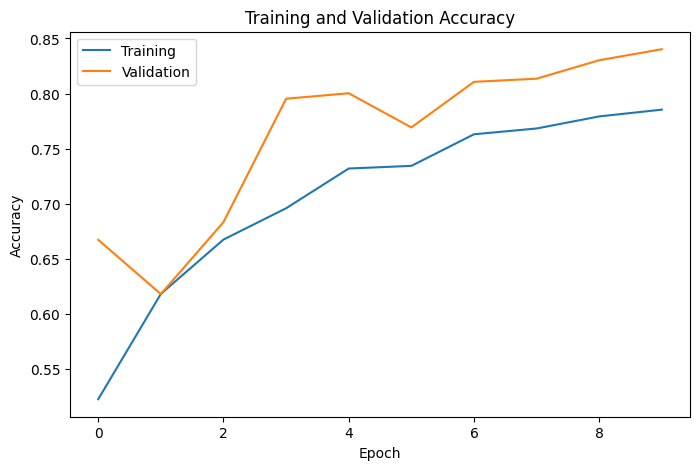

In [ ]:
#Accuracy Graph Visualisation

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])
plt.show()

**INSIGHT**
* not overfitting
* if epoch increased further, model may show an improved performance

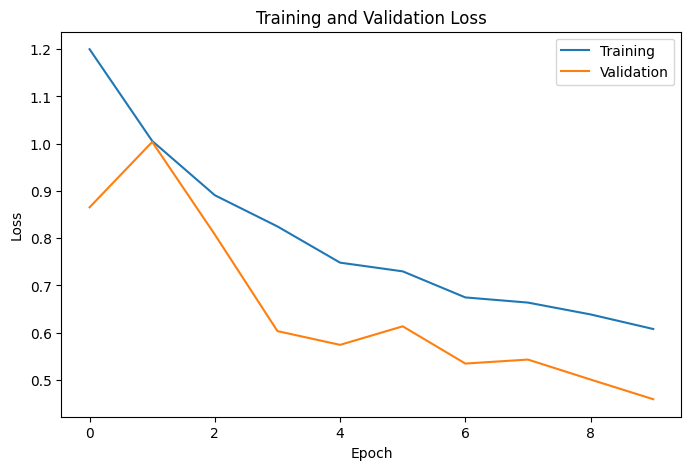

In [ ]:
#Plot Loss Graph Visualisation
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])
plt.show()

**INSIGHT**
* Stable Training
* Shows successful convergence

**Analytical Question 3 (Markdown):
Explain how convolution and pooling operations contribute to feature extraction in CNNs.**

* Convolution layers use filters to detect important image features such as edges, textures, shapes, and patterns. As the network becomes deeper, it learns more complex features that help distinguish different scene classes.
* Pooling layers reduce the spatial dimensions of feature maps while preserving important information.
* This reduces computational cost, helps prevent overfitting, and allows the model to focus on the most relevant features for classification.

#**Task 4: Model Evaluation**

Evaluate the trained model on the test dataset.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.8300 - loss: 0.4697
Test Loss: 0.4696941673755646
Test Accuracy: 0.8299999833106995


**INSIGHT**
* The test accuracy (83.0%) is very close to the validation accuracy (84.0%).
* The test loss of 0.47 is relatively low, indicating that the model is making confident predictions on most test images.

• Generate performance metrics and a confusion matrix.

In [ ]:
import numpy as np

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step


In [ ]:
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(true_classes,predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.83      0.77      0.80       437
      forest       0.96      0.93      0.95       474
     glacier       0.83      0.77      0.80       553
    mountain       0.81      0.75      0.78       525
         sea       0.78      0.88      0.83       510
      street       0.79      0.89      0.84       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



**INSIGHT**
* Forest easiest to classify
* Mountains harder to classify due to low Recall and F1-score
* Accuracy = 83%
* Macro F1 = 83%
* Weighted F1 = 83%

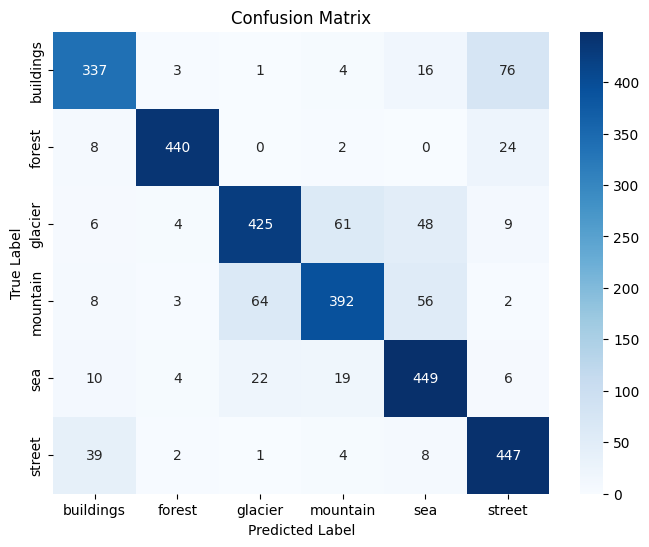

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes,predicted_classes)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**INSIGHT**
Glacier predicted as Mountain = 61
Mountain predicted as Glacier = 64

In [ ]:
# Save baseline model

model.save("cnn_baseline.h5")
print("Baseline model saved successfully")

Baseline model saved successfully


**Analytical Question 4:
Which scene classes are most frequently confused, and what semantic similarities could explain
these errors?**

*The confusion matrix indicates that glacier and mountain scenes are the most frequently misclassified, with 61 glacier images predicted as mountain and 64 mountain images predicted as glacier. This is likely due to their similar visual characteristics.
* Another common confusion occurs between buildings and street scenes. Both classes contain urban elements such as roads, buildings, and vehicles, making them visually similar.
* Overall, misclassifications mainly occur between classes that share common visual patterns and semantic characteristics.

#**Task 5: Error and Failure Analysis**

• Identify incorrectly classified samples.


In [ ]:
wrong_indices = np.where(predicted_classes != true_classes)[0]
print("Number of Misclassified Images:",len(wrong_indices))

Number of Misclassified Images: 510


• Visualize misclassified images with true and predicted labels.

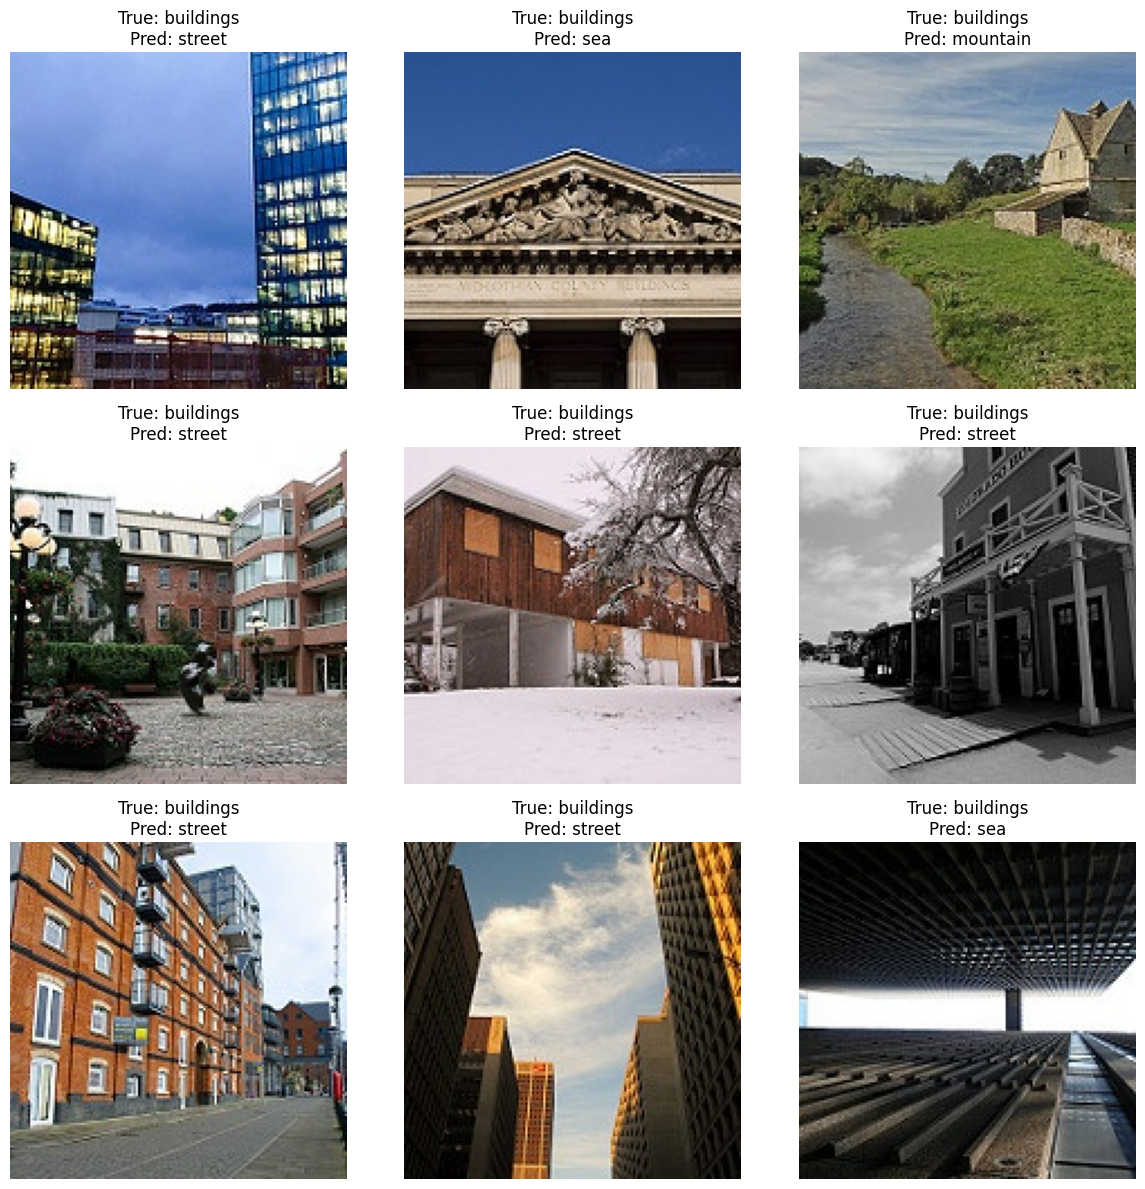

In [ ]:
plt.figure(figsize=(12,12))
filenames = test_generator.filenames
for i, idx in enumerate(wrong_indices[:9]):
    img_path = os.path.join(test_path,filenames[idx])
    img = load_img(img_path,target_size=(150,150))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    true_label = class_names[true_classes[idx]]
    pred_label = class_names[predicted_classes[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Count Errors
total_errors = np.sum(predicted_classes != true_classes)
print("Total Errors:", total_errors)

Total Errors: 510


**Analytical Question 5: Based on failure cases, what environmental or visual factors appear to mislead the model?**
* The failure analysis suggests that the model is often misled by scenes that share similar visual characteristics.
* Glacier and mountain images are frequently confused because both contain rocky terrain, snow-covered surfaces, and similar landscape structures.
* Buildings and street scenes are also difficult to distinguish when urban features such as roads, buildings, and vehicles appear together in the image.


#**Task 6: Model Refinement**

• Improve the model through architectural changes, regularization, or training strategy
adjustments.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

/tmp/ipykernel_715/632844194.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model2 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

In [ ]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history2 = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 199s 495ms/step - accuracy: 0.7837 - loss: 0.5947 - val_accuracy: 0.8805 - val_loss: 0.3156
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 89s 252ms/step - accuracy: 0.8391 - loss: 0.4414 - val_accuracy: 0.8873 - val_loss: 0.3047
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 234ms/step - accuracy: 0.8511 - loss: 0.4094 - val_accuracy: 0.8912 - val_loss: 0.2979
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 230ms/step - accuracy: 0.8566 - loss: 0.3932 - val_accuracy: 0.8937 - val_loss: 0.2929
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.8641 - loss: 0.3802 - val_accuracy: 0.8937 - val_loss: 0.2826
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.8679 - loss: 0.3673 - val_accuracy: 0.8848 - val_loss: 0.3020
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 228ms/step - accuracy: 0.8669 - loss: 0.3629 - val_accuracy: 0.8916 - val_loss: 0.2937
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 228ms/step - accuracy: 0.8715 - loss: 

**INSIGHT**
* The model performance improved tremendously

In [ ]:
os.makedirs("models", exist_ok=True)
model2.save("models/intel_mobilenet.h5")

• Re-evaluate the improved model.

In [ ]:
mobile_loss, mobile_acc = model2.evaluate(test_generator)
print("MobileNetV2 Accuracy:", mobile_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 167ms/step - accuracy: 0.9037 - loss: 0.2676
MobileNetV2 Accuracy: 0.9036666750907898


In [ ]:
predictions2 = model2.predict(test_generator)
predicted_classes2 = np.argmax(predictions2, axis=1)
true_classes = test_generator.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step


In [ ]:
#Classification Report
class_names = list(test_generator.class_indices.keys())
print(classification_report(true_classes,predicted_classes2,target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.89      0.93      0.91       437
      forest       0.97      0.99      0.98       474
     glacier       0.85      0.85      0.85       553
    mountain       0.86      0.83      0.85       525
         sea       0.93      0.93      0.93       510
      street       0.92      0.91      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.91      0.91      3000
weighted avg       0.90      0.90      0.90      3000



In [ ]:
#confusion Matrix
cm2 = confusion_matrix(true_classes,predicted_classes2)

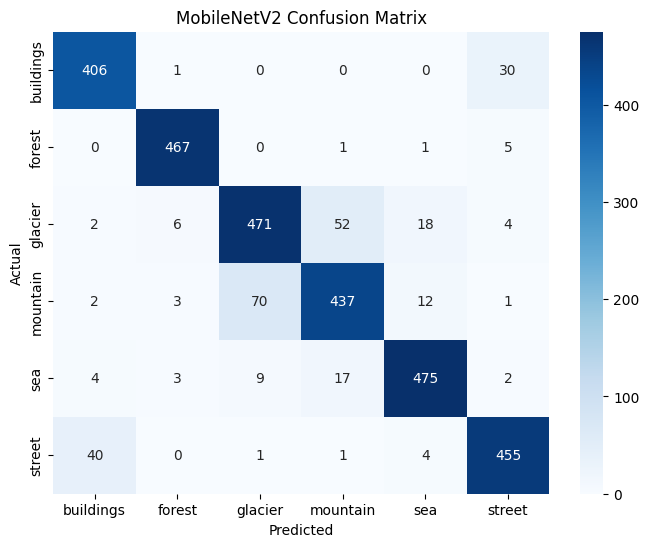

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [ ]:
cnn_loss, cnn_acc = model.evaluate(test_generator)
mobile_loss, mobile_acc = model2.evaluate(test_generator)
print("Original CNN Accuracy :", round(cnn_acc*100,2), "%")
print("MobileNetV2 Accuracy :", round(mobile_acc*100,2), "%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8300 - loss: 0.4697
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9037 - loss: 0.2676
Original CNN Accuracy : 83.0 %
MobileNetV2 Accuracy : 90.37 %


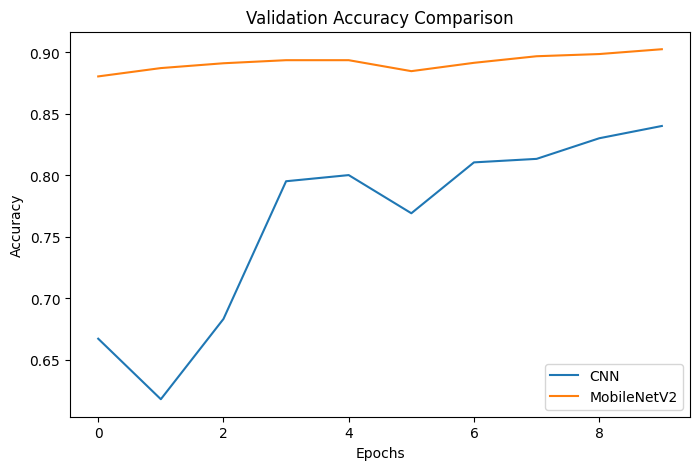

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['val_accuracy'],label='CNN')
plt.plot(history2.history['val_accuracy'],label='MobileNetV2')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Analytical Question 6 (Markdown):
What performance gains were achieved, and what trade-offs (e.g., complexity, training time) were
introduced?**

* The refined model used MobileNetV2 transfer learning, which leverages features learned from a large image dataset. Compared to the baseline CNN, the improved model achieved higher accuracy and better generalization on the test dataset.

* The main performance gain came from the pretrained feature extractor, which captures complex image patterns more effectively than a CNN trained from scratch.

* However, these improvements introduced trade-offs. The MobileNetV2 model is more complex, requires additional memory, and takes longer to train compared to the baseline CNN. Despite these trade-offs, the improved accuracy and robustness make it a better choice for real-world scene classification tasks.

**Analytical Question 7 (Markdown):What are the limitations of deploying deep learning image classifiers in real-time applications?**

ANS:

Real-time deployment faces challenges such as latency, hardware limitations, changing environmental conditions, domain shifts, and prediction uncertainty. Models may perform poorly on images significantly different from training data, making continuous monitoring and retraining necessary.